# 41 — Calculate HPL, RTPL and Profit and Loss Attribution

Compare the full pricing representation with the IMA risk-model representation for the same frozen portfolio.

HPL means Hypothetical Profit and Loss. RTPL means Risk-Theoretical Profit and Loss. PLA means Profit and Loss Attribution. Differences arise from NMRFs, grid simplification, basis effects and nonlinear pricing.

This step uses: Frozen portfolio snapshots and next-day joint market changes.

It produces: Daily HPL and RTPL plus Spearman, KS and green/amber/red classification.

> Basel norm applied: MAR32.20–MAR32.44 use 250 observations, Spearman correlation and Kolmogorov-Smirnov distribution separation.

$$HPL_{t+1}=V(P_t,M_{t+1})-V(P_t,M_t)$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260901T122303Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
daily=stage('19_daily_hpl_rtpl_apl'); pla=stage('20_pla_results'); daily['date']=pd.to_datetime(daily.date)
display(pla)
credit=pla[pla.desk=='Credit'].iloc[0]; print(f"Credit desk: Spearman {credit.spearman_correlation:.3f}, KS {credit.ks_statistic:.3f} → {credit.pla_zone}.")
print('Displayed sample: final 10 daily Credit desk observations from the 250-day PLA window.')
display(crore_table(daily[daily.desk=='Credit'][['date','hpl_inr','rtpl_inr','apl_inr']].tail(10),['hpl_inr','rtpl_inr','apl_inr']))

,desk,observations,spearman_correlation,ks_statistic,pla_zone,pla_reason
0,Commodity,250,1.0000,0.0080,GREEN,Both Spearman and KS metrics satisfy the green...
1,Credit,250,0.9377,0.0760,GREEN,Both Spearman and KS metrics satisfy the green...
2,Equity,250,0.9995,0.0280,GREEN,Both Spearman and KS metrics satisfy the green...
3,FX,250,1.0000,0.0120,GREEN,Both Spearman and KS metrics satisfy the green...
4,Rates,250,1.0000,0.0080,GREEN,Both Spearman and KS metrics satisfy the green...


Credit desk: Spearman 0.938, KS 0.076 → GREEN.
Displayed sample: final 10 daily Credit desk observations from the 250-day PLA window.


,date,Hpl (INR crore),Rtpl (INR crore),Apl (INR crore)
990,2026-06-17,-0.0781,-0.0390,-0.0783
991,2026-06-18,-0.0335,-0.0394,-0.0335
992,2026-06-19,0.0236,0.0122,0.0236
993,2026-06-22,-0.0610,-0.0382,-0.0610
994,2026-06-23,0.0964,0.0593,0.0964
995,2026-06-24,0.0243,0.0043,0.0243
996,2026-06-25,0.0609,-0.0008,0.0609
997,2026-06-26,0.0505,0.0410,0.0505
998,2026-06-29,-0.0768,-0.0701,-0.0768
999,2026-06-30,0.1653,0.1199,0.1623


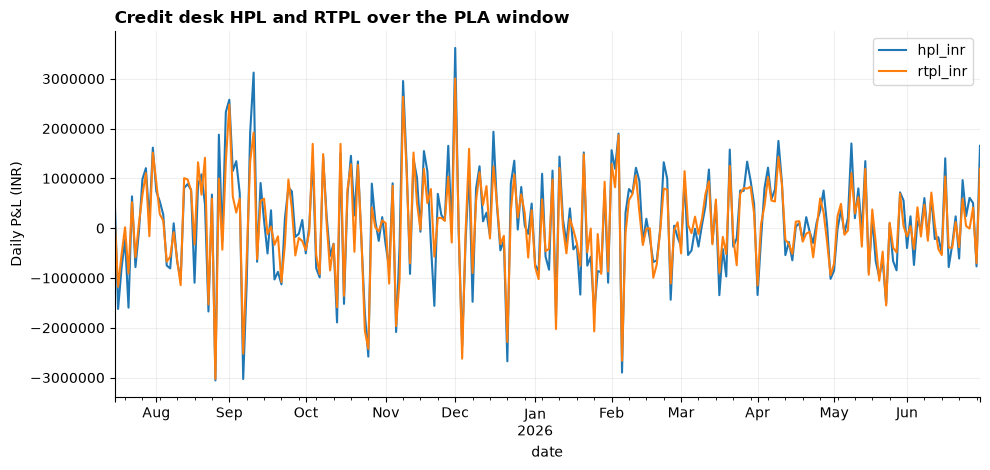

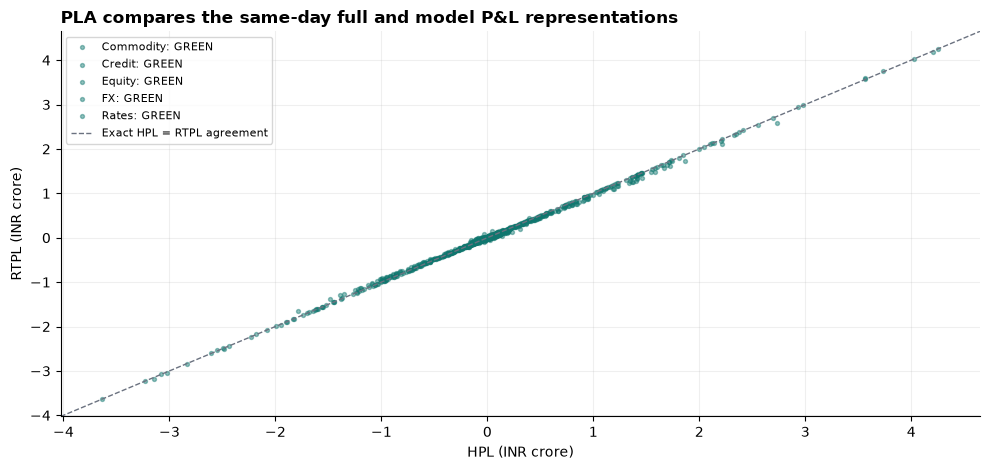

In [3]:
sample=daily[daily.desk=='Credit'].tail(250); ax=sample.plot(x='date',y=['hpl_inr','rtpl_inr']); ax.set_ylabel('Daily P&L (INR)'); ax.ticklabel_format(axis='y',style='plain'); ax.set_title('Credit desk HPL and RTPL over the PLA window',loc='left',weight='bold'); plt.tight_layout(); plt.show()
fig,ax=plt.subplots();
colors={'GREEN':'#0F766E','AMBER':'#F59E0B','RED':'#DC2626'}
for desk,g in daily.groupby('desk'):
 s=g.tail(250); zone=pla.loc[pla.desk==desk,'pla_zone'].iloc[0]; ax.scatter(s.hpl_inr/INR_CRORE,s.rtpl_inr/INR_CRORE,s=8,alpha=.45,label=f'{desk}: {zone}',color=colors[zone])
low=min(ax.get_xlim()[0],ax.get_ylim()[0]); high=max(ax.get_xlim()[1],ax.get_ylim()[1]); ax.plot([low,high],[low,high],color='#6B7280',linestyle='--',linewidth=1,label='Exact HPL = RTPL agreement'); ax.set_xlim(low,high); ax.set_ylim(low,high)
ax.set_xlabel('HPL (INR crore)'); ax.set_ylabel('RTPL (INR crore)'); ax.set_title('PLA compares the same-day full and model P&L representations',loc='left',weight='bold'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The first chart overlays Credit desk HPL and RTPL for the 250-day PLA window. Close movement indicates that the risk model explains the full-pricing P&L, while persistent gaps weaken attribution. The scatter plot applies the same comparison to every tested desk: points close to the 45-degree relationship indicate close HPL–RTPL agreement, while wider dispersion is consistent with amber or red classification.